In [1]:
#importing exernal librarys
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing from the local file
from code import *

In [15]:
#loading data
from sklearn.datasets import load_digits

data = load_digits()
images = data.images / 16.0
targets = data.target

In [16]:
#one hot encoding to data
one_hot_labels = np.zeros(((len(targets)),10))

for i,l in enumerate(targets):
  one_hot_labels[i][l] = 1
targets = one_hot_labels

In [17]:
#taking 1100 images as data
images = images[:1100]
targets = targets[:1100]

In [18]:
#split the data from train and test
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(images,targets,random_state=42,test_size=0.1)

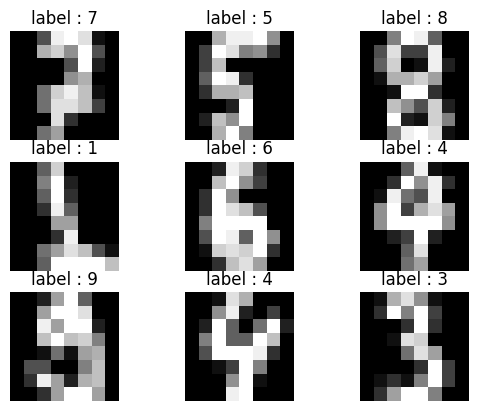

In [19]:
#visualizing some images
for i in range(1,10):
  plt.subplot(3,3,i)
  idx = np.random.randint(0,len(X_train))
  plt.imshow(X_train[idx],cmap="gray")
  label_t = np.argmax(y_train[idx])
  plt.title(f"label : {label_t}")
  plt.axis(False)



In [20]:
#making the architecture of the model
model = CNN(
    conv_index = [(3,4)], #conv layer 3 * 3 and 4 output layer
    pooling_index = 2,    #2*2 ang pooling
    ann_input = 36,       #according to fladden size
    ann_layers = [16,10]  #hidden 16 neuron , output 10(digit class)
)

In [21]:
#the model
model

Convolution Neural Network of :

[Input Layer  ,

Convolution Layer of : [Convolution layer(3 * 3), Convolution layer(3 * 3), Convolution layer(3 * 3), Convolution layer(3 * 3)] ,

Average Pooling layer of 2 * 2 ,

Flatten Layer. ,

Layer of : [ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36), ReLUNeuron(36)] ,

Layer of : [LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16), LinearNeuron(16)]]

In [24]:
#trainig the model
%%time

epochs = 30
lr = 0.01
loss_fn = CrossEntropyLoss()
softmax = Softmax()

for epoch in range(epochs):
  acc = 0
  for i in range(len(X_train)):
    X , y = X_train[i:i+1] , y_train[i]
    y_logits = model(X)
    y_prob = softmax(y_logits)



    loss = loss_fn(y_prob,y) #crossentropy loss
    for pm in model.parameters():
      pm.grad = 0

    loss.backward()
    for pm in model.parameters():
      pm.data -= lr * pm.grad

    y_pred = np.argmax([y_t.data for y_t in y_prob])
    if y_pred == np.argmax(y):
      acc += 1


  acc /= len(X_train)
  print(f"Epoch {epoch} | Loss: {loss.data} | acc : {acc}")


Epoch 0 | Loss: 0.1927975957518525 | acc : 0.14747474747474748
Epoch 1 | Loss: 0.23716582283333076 | acc : 0.17373737373737375
Epoch 2 | Loss: 0.2282524820990994 | acc : 0.27575757575757576
Epoch 3 | Loss: 0.20162641329182773 | acc : 0.3383838383838384
Epoch 4 | Loss: 0.17303808472425303 | acc : 0.3838383838383838
Epoch 5 | Loss: 0.1454474030348217 | acc : 0.4535353535353535
Epoch 6 | Loss: 0.1180398789376955 | acc : 0.5414141414141415
Epoch 7 | Loss: 0.09492212793665034 | acc : 0.6090909090909091
Epoch 8 | Loss: 0.08404964896424644 | acc : 0.6696969696969697
Epoch 9 | Loss: 0.06671520447019516 | acc : 0.7333333333333333
Epoch 10 | Loss: 0.05622452347834857 | acc : 0.7696969696969697
Epoch 11 | Loss: 0.04885035891867511 | acc : 0.804040404040404
Epoch 12 | Loss: 0.042837478031310355 | acc : 0.8212121212121212
Epoch 13 | Loss: 0.03804290815612882 | acc : 0.8434343434343434
Epoch 14 | Loss: 0.03461311925328229 | acc : 0.8616161616161616
Epoch 15 | Loss: 0.031100642986680794 | acc : 0.868

In [26]:
#testing model
y_test_pred = []
acc = 0
for i in range(len(X_test)):
  X , y = X_test[i:i+1] , y_test[i]
  y_logits = model(X)
  y_prob = softmax(y_logits)

  loss = loss_fn(y_prob,y)

  y_pred = np.argmax([y_t.data for y_t in y_prob])
  if y_pred == np.argmax(y):
    acc += 1
  y_test_pred.append(y_pred)


acc /= len(X_test)
print(f"Test Loss: {loss.data} | Test acc : {acc}")

Test Loss: 0.29397258351298555 | Test acc : 0.9181818181818182


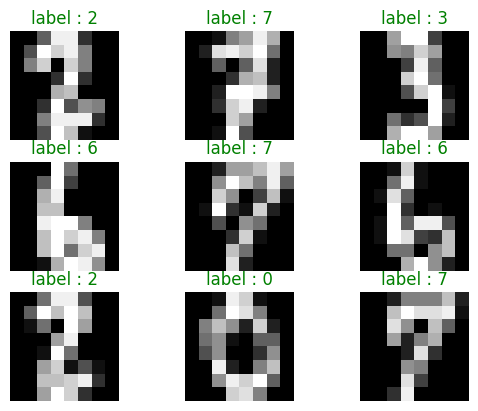

In [31]:
#test model with visualize
for i in range(1,10):
  plt.subplot(3,3,i)
  idx = np.random.randint(0,len(X_test))

  image_t = X_test[idx]
  label_t = np.argmax(y_test[idx])
  pred_t = y_test_pred[idx]
  color = "green" if label_t == pred_t else "red"

  plt.imshow(image_t,cmap="gray")
  plt.title(f"label : {pred_t}",color=color)
  plt.axis(False)

<Axes: >

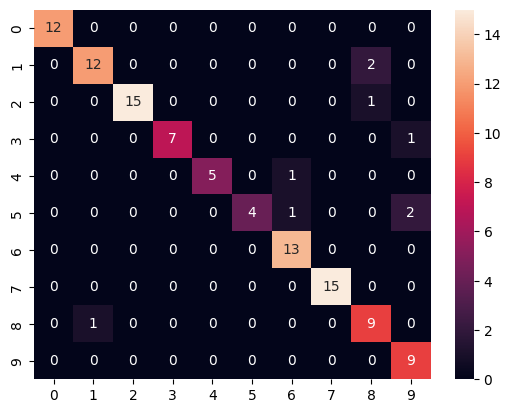

In [34]:
#confusion matrix of the model
from sklearn.metrics import confusion_matrix

y_test_t = [np.argmax(row) for row in y_test]
cm = confusion_matrix(y_test_t , y_test_pred)
sns.heatmap(cm,annot=True)